# Decision Analysis - Project 1


### 1. Dataset Description

**Dataset:**
The data comes from the Otomoto website and includes listings for 15 popular cars on the Polish used car market (filter: Car for city).

For the decision analysis, we selected 5 criteria, divided into cost-type attributes (to be minimized) and gain-type attributes (to be maximized):

- Price in PLN (price_pln) - a cost-type criterion. The lower the purchase price, the more preferable the option.

- Year of manufacture (year_of_manufacture) - a gain-type criterion. Newer models are rated higher.

- Mileage (mileage_km) - a cost-type criterion. Lower mileage is preferred.

- Fuel consumption (fuel_consumption_l100km) - a cost-type criterion. Lower fuel consumption is preferred.

- Appearance (appearance) - a gain-type criterion. A subjective assessment of visual appeal on a scale of 1-10.

Power exists in the raw dataset but is not used in the final UTA/AHP model.


### 2. Data Source

Data was scrapped by hand from Otomoto. Filter was:

- Year of production: 2014 - 2016
- Price: 30000 - 50000
- Segment: City


### 3. The point of view of the decision maker

The decision maker is an average driver/buyer looking for a car for everyday use. They prioritize reliability (low mileage and newer model year) and low running costs (price, fuel consumption), while also considering appearance.


### 4. What is the number of alternatives considered? Were there more of them in the original data set?

Exactly 15 alternatives are being considered. Otomoto has thousands of offers, so we selected only 15 of them.


### 5. Describe one of the alternatives considered

Renault Clio (ID 10):

- Price: 34 000 PLN (Cost)
- Year: 2016 (Gain)
- Mileage: 76 270 km (Cost)
- Fuel Consumption: 5.8 L/100km (Cost)
- Appearance: 6 (Gain)


### 6. What is the number of criteria considered? Were there more of them in the original data set?

Five criteria are considered in the final model: price, model year, mileage, fuel economy, and appearance. We selected these from the original set because they are the most important from the perspective of the decision-maker. The dataset contains additional fields (for example id/link metadata and power), but they are not used in the final UTA/AHP model.


### 7. Domains and nature of criteria

- price: Continuous, range: [30900, 49999], type: Cost
- year: Discrete, values: [2014, 2015, 2016], type: Gain
- mileage: Continuous, range: [71,000, 188,000], type: Cost
- fuel_consumption: Continuous, range: [5.1, 8.9], type: Cost
- appearance: Discrete, values: [4, 5, 6, 7, 8, 9], type: Gain


### 8. Are all criteria equally important? What about weightings?

No, the criteria are not equally important. The most important factors are cost-effectiveness and mechanical condition.
Estimated weights on a scale of 1-10:

- Price: 9
- Mileage: 8
- Fuel economy: 6
- Appearance: 6
- Year of manufacture: 2

There are no criteria that are completely unimportant, but year has marginal importance in this setup.


### 9. Are there dominated alternatives?

In our dataset, there are no strictly dominant alternatives (where car A is better than or equal to car B on all modeled criteria). For example, a cheaper car typically has trade-offs in mileage, year, fuel consumption, or appearance.


### 10. What should the theoretically best alternative look like?

The theoretical best alternative is low-price, low-mileage, low-fuel-consumption, relatively new, and with good appearance.


### 11. Which alternative seems to be the best?

Hyundai i20 (ID 2) - due to low fuel consumption (5.1), low mileage (71200) and very good apperance (7/10). It has weaknesses (the worst possible year of production)


### 12. Which alternative seems to be the worst?

Ford Focus (ID 13) - due to the highest mileage in the dataset (188000), relatively high fuel consumption (7.2), and only an average price (35900). It has some strengths (decent appearance 7/10 and the newest year of production).


### 13. Provide at least 4 pairwise comparisons between alternatives in your dataset.

- Renault Clio (ID 10) > Skoda Fabia (ID 11) - due to lower mileage (76,270 vs. 124,000) at similar price and fuel economy.
- Hyundai i20 (ID 2) > Toyota Yaris (ID 8) - due to lower price (36,950 vs. 41,500), lower mileage (71,200 vs. 119,000), lower fuel consumption, and better appearance. Yaris wins mainly on year.
- Seat Ibiza (ID 9) > Ford Focus (ID 13) - due to better price (30,900 vs. 35,900) and lower mileage (156,000 vs. 188,000), which is enough under the assumed preferences.
- Kia Venga (ID 1) > Chevrolet Trax (ID 6) - due to lower price (32,500 vs. 34,900) and lower mileage (82,000 vs. 97,500).


In [51]:
import pandas as pd
import pulp
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("cars_dataset.csv")
df.columns = df.columns.str.strip()
df.set_index("id", inplace=True)
CRITERIA = ["price", "year", "mileage", "fuel_consumption", "appearance"]
df = df[CRITERIA + ["name"]]
display(df.head())

,price,year,mileage,fuel_consumption,appearance,name
id,,,,,,
1,32500,2015,82000,7.6,4,Kia Venga
2,36950,2014,71200,5.1,7,Hyundai i20
3,33800,2014,180686,8.0,9,BMW 118d
4,37900,2016,135000,7.2,7,Renault Megane
5,38700,2015,180000,6.2,6,Nissan Qashqai


## 2.1 UTA

We define a stronger set of pairwise preferences that better reflects the decision-maker profile: price and mileage are treated as key drivers, with year and fuel consumption also important, while appearance is secondary.

We still include one intentional 3-comparison cycle to demonstrate inconsistency handling and minimal-removal analysis.


In [52]:
# breakpoints for each criterion
BP = {
    "price": [31000, 35500, 50000],
    "year": [2014, 2015, 2016],
    "mileage": [70000, 110000, 190000],
    # "power": [86, 120, 218],
    "fuel_consumption": [5.0, 7.0, 9.0],
    "appearance": [4, 7, 9],
}
DIRECTIONS = {
    "price": "cost",
    "year": "gain",
    "mileage": "cost",
    # "power": "gain",
    "fuel_consumption": "cost",
    "appearance": "gain",
}

EPS = 0.02
MIN_W = 0.15
MAX_W = 0.4
BIG_M = 1e3

PREFS = [
    (2, 1),  # Hyundai i20 > Kia Venga (lower price, lower mileage, lower fuel)
    (10, 11),  # Renault Clio > Skoda Fabia (lower mileage at same price tier)
    (2, 8),  # Hyundai i20 > Toyota Yaris (cheaper, lower mileage, better appearance)
    (9, 13),  # Seat Ibiza > Ford Focus (cheapest vs highest mileage)
    (1, 6),  # Kia Venga > Chevrolet Trax (lower price, lower mileage)
    # cycle
    (3, 4),  # BMW 118d > Renault Megane
    (4, 5),  # Renault Megane > Nissan Qashqai
    (5, 3),  # Nissan Qashqai > BMW 118d
]

PREF_LABELS = {
    (2, 1): "Hyundai i20 > Kia Venga",
    (10, 11): "Renault Clio > Skoda Fabia",
    (2, 8): "Hyundai i20 > Toyota Yaris",
    (9, 13): "Seat Ibiza > Ford Focus",
    (1, 6): "Kia Venga > Chevrolet Trax",
    (3, 4): "BMW 118d > Renault Megane  [cycle]",
    (4, 5): "Renault Megane > Nissan Qashqai  [cycle]",
    (5, 3): "Nissan Qashqai > BMW 118d  [cycle]",
}

In [53]:
def get_utility(car_id, u_vars):
    row = df.loc[car_id]
    result = pulp.lpSum([])

    for crit in CRITERIA:
        pts = BP[crit]
        val = float(row[crit])
        val = max(pts[0], min(pts[-1], val))

        seg = len(pts) - 2
        for i in range(len(pts) - 1):
            if val <= pts[i + 1]:
                seg = i
                break

        x0 = pts[seg]
        x1 = pts[seg + 1]
        u0 = u_vars[(crit, seg)]
        u1 = u_vars[(crit, seg + 1)]
        t = (val - x0) / (x1 - x0)
        result = result + u0 + t * (u1 - u0)

    return result


def build_model(model_name, pref_list, use_binary=False):
    model = pulp.LpProblem(model_name, pulp.LpMinimize)

    u = {}
    for crit in CRITERIA:
        for k in range(len(BP[crit])):
            u[(crit, k)] = pulp.LpVariable(f"u_{crit}_{k}", lowBound=0)

    for crit in CRITERIA:
        pts = BP[crit]
        for k in range(len(pts) - 1):
            if DIRECTIONS[crit] == "gain":
                model += u[(crit, k + 1)] - u[(crit, k)] >= EPS
            else:
                model += u[(crit, k)] - u[(crit, k + 1)] >= EPS

    for crit in CRITERIA:
        pts = BP[crit]
        if DIRECTIONS[crit] == "gain":
            model += u[(crit, 0)] == 0
        else:
            model += u[(crit, len(pts) - 1)] == 0

    weight_list = []
    for crit in CRITERIA:
        pts = BP[crit]
        if DIRECTIONS[crit] == "gain":
            w = u[(crit, len(pts) - 1)]
        else:
            w = u[(crit, 0)]
        model += w >= MIN_W
        model += w <= MAX_W
        weight_list.append(w)

    model += pulp.lpSum(weight_list) == 1

    bin_vars = {}
    for i in range(len(pref_list)):
        a, b = pref_list[i]
        ua = get_utility(a, u)
        ub = get_utility(b, u)
        if use_binary:
            v = pulp.LpVariable(f"v_{i}", cat=pulp.const.LpBinary)
            bin_vars[i] = v
            model += ua - ub + BIG_M * v >= EPS
        else:
            model += ua - ub >= EPS

    model += 0
    return model, u, bin_vars


m1, u1, bv1 = build_model("find_min_removals", PREFS, use_binary=True)
m1 += pulp.lpSum(bv1.values())
m1.solve(pulp.PULP_CBC_CMD(msg=False))

n_remove = int(round(pulp.value(m1.objective)))
print(f"Status: {pulp.LpStatus[m1.status]}")
print(f"Min removals: {n_remove}")
print()

found = []
cuts = []

for it in range(10):
    m, u_it, bv = build_model(f"enum_{it}", PREFS, use_binary=True)
    m += pulp.lpSum(bv.values())
    m += pulp.lpSum(bv.values()) == n_remove

    for prev in cuts:
        m += pulp.lpSum(bv[i] for i in prev) <= n_remove - 1

    m.solve(pulp.PULP_CBC_CMD(msg=False))
    if m.status != 1:
        break

    removed = [i for i in range(len(PREFS)) if pulp.value(bv[i]) > 0.5]
    kept = [PREFS[i] for i in range(len(PREFS)) if i not in removed]

    found.append({"removed": [PREFS[i] for i in removed], "consistent": kept})
    cuts.append(removed)

print(f"Found {len(found)} consistent subset(s):\n")
for k in range(len(found)):
    print(f"Subset {k+1}:")
    print(f"Removed: {[PREF_LABELS[p] for p in found[k]['removed']]}")
    print(f"Kept: {len(found[k]['consistent'])} preferences")
    print()

/Users/ponteski/.config/miniforge3/lib/python3.13/site-packages/pulp/pulp.py:1865: UserWarning: Overwriting previously set objective.
  warnings.warn("Overwriting previously set objective.")


Status: Optimal
Min removals: 1

Found 3 consistent subset(s):

Subset 1:
Removed: ['BMW 118d > Renault Megane  [cycle]']
Kept: 7 preferences

Subset 2:
Removed: ['Nissan Qashqai > BMW 118d  [cycle]']
Kept: 7 preferences

Subset 3:
Removed: ['Renault Megane > Nissan Qashqai  [cycle]']
Kept: 7 preferences



- Hyundai i20 > Kia Venga
- Renault Clio > Skoda Fabia
- Hyundai i20 > Toyota Yaris
- Seat Ibiza > Ford Focus
- Kia Venga > Chevrolet Trax
- Renault Megane > Nissan Qashqai  [cycle]
- Nissan Qashqai > BMW 118d  [cycle]

status: Optimal

weights:
price: 0.150
year: 0.150
mileage: 0.150
fuel_consumption: 0.400
appearance: 0.150


,name,utility,price,year,mileage,fuel_consumption,appearance
id,,,,,,,
10,Renault Clio,0.677623,34000,2016,76270,5.8,6
2,Hyundai i20,0.675100,36950,2014,71200,5.1,7
11,Skoda Fabia,0.592167,33700,2016,124000,5.7,6
9,Seat Ibiza,0.553500,30900,2016,156000,6.5,7
15,Honda Jazz,0.504978,33200,2014,100400,5.4,5
7,MINI Cooper S 60,0.329751,49999,2015,71000,7.7,9
4,Renault Megane,0.328440,37900,2016,135000,7.2,7
8,Toyota Yaris,0.321807,41500,2015,119000,5.9,5
13,Ford Focus,0.317948,35900,2016,188000,7.2,7


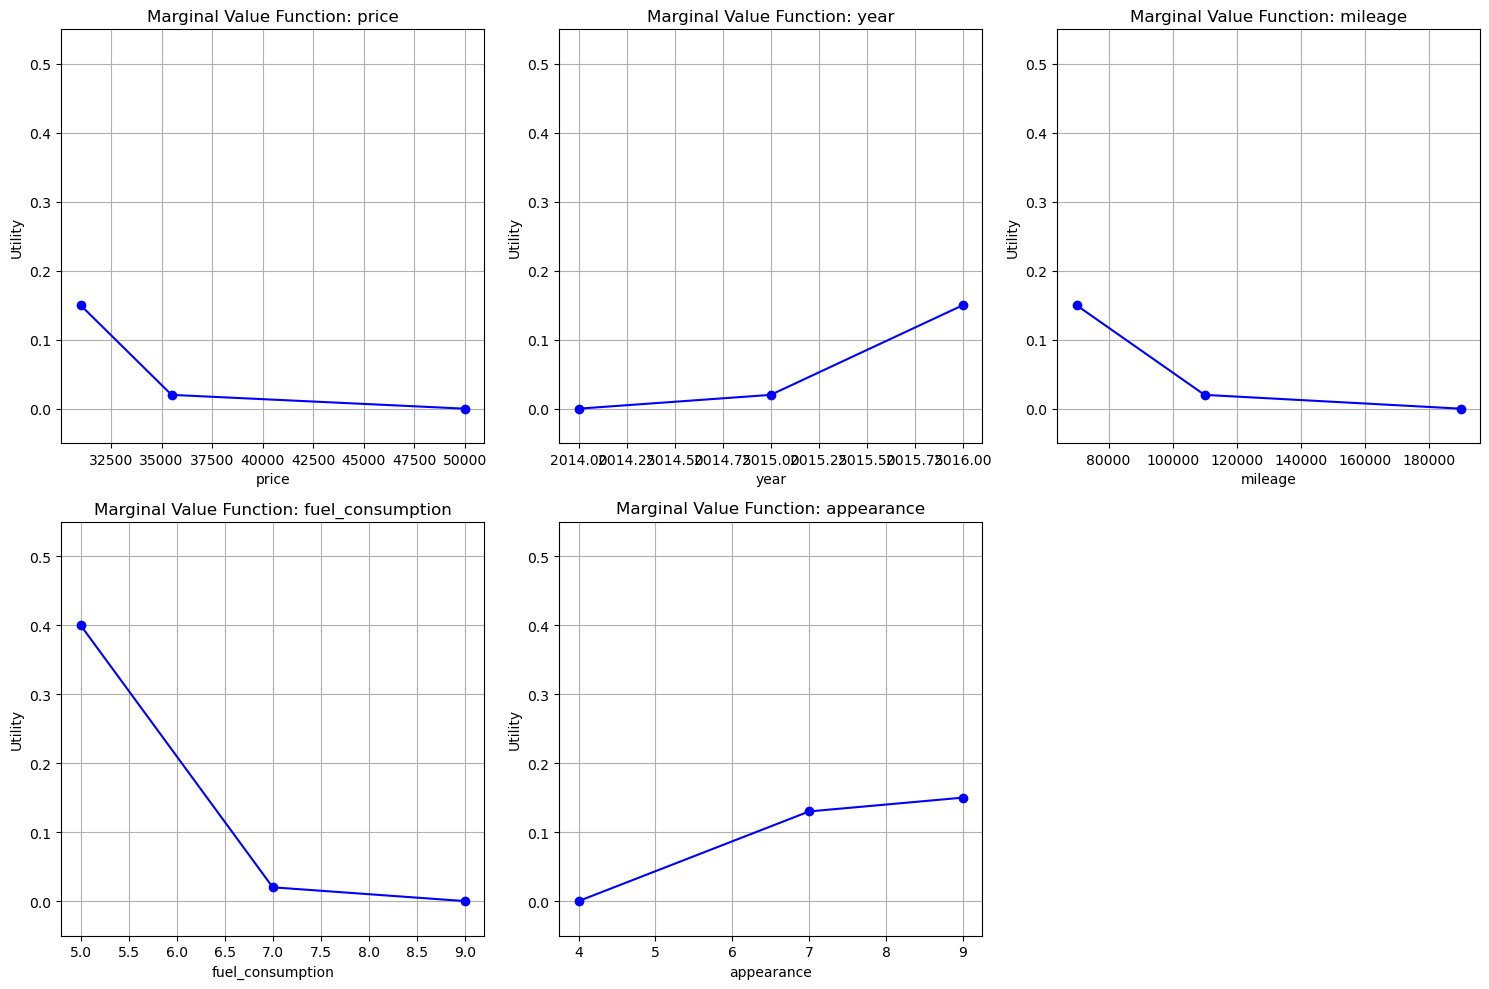

In [54]:
selected_prefs = found[0]["consistent"]
for p in selected_prefs:
    print(f"- {PREF_LABELS[p]}")

m_final, u_final, _ = build_model(
    "uta_consistent_set", selected_prefs, use_binary=False
)

m_final.solve(pulp.PULP_CBC_CMD(msg=False))
print(f"\nstatus: {pulp.LpStatus[m_final.status]}")

weights = {}
for crit in CRITERIA:
    pts = BP[crit]
    if DIRECTIONS[crit] == "gain":
        w = pulp.value(u_final[(crit, len(pts) - 1)])
    else:
        w = pulp.value(u_final[(crit, 0)])
    weights[crit] = w

print("\nweights:")
for crit, w in weights.items():
    print(f"{crit}: {w:.3f}")

utilities = {}
for car_id in df.index:
    val = pulp.value(get_utility(car_id, u_final))
    utilities[car_id] = val

df_res = df.copy()
df_res["utility"] = pd.Series(utilities)
df_res = df_res.sort_values("utility", ascending=False)
display(df_res[["name", "utility"] + CRITERIA].head(15))

plt.figure(figsize=(15, 10))
for i, crit in enumerate(CRITERIA):
    plt.subplot(2, 3, i + 1)

    x_vals = BP[crit]
    y_vals = [pulp.value(u_final[(crit, k)]) for k in range(len(x_vals))]

    plt.plot(x_vals, y_vals, marker="o", linestyle="-", color="b")
    plt.title(f"Marginal Value Function: {crit}")
    plt.xlabel(crit)
    plt.ylabel("Utility")
    plt.ylim(-0.05, 0.55)
    plt.grid(True)

plt.tight_layout()
plt.show()

## 2.2 UTA with Most Discriminant Value Function

For the largest set of consistent preferences, we now solve a problem that maximizes the distance between utilities of alternatives in preference relationships. This helps identify the value function that best discriminates between preferred and less-preferred alternatives.


In [55]:
# Select the largest consistent set (typically the first one found)
selected_prefs = found[0]["consistent"]

# Build model with discriminant objective
model_discr = pulp.LpProblem("UTA_discriminant", pulp.LpMaximize)

# Create utility variables
u_discr = {}
for crit in CRITERIA:
    for k in range(len(BP[crit])):
        u_discr[(crit, k)] = pulp.LpVariable(f"u_{crit}_{k}", lowBound=0)

# Monotonicity constraints
for crit in CRITERIA:
    pts = BP[crit]
    for k in range(len(pts) - 1):
        if DIRECTIONS[crit] == "gain":
            model_discr += (
                u_discr[(crit, k + 1)] - u_discr[(crit, k)] >= EPS,
                f"mono_{crit}_{k}",
            )
        else:
            model_discr += (
                u_discr[(crit, k)] - u_discr[(crit, k + 1)] >= EPS,
                f"mono_{crit}_{k}",
            )

# Normalization constraints
for crit in CRITERIA:
    pts = BP[crit]
    if DIRECTIONS[crit] == "gain":
        model_discr += u_discr[(crit, 0)] == 0, f"norm_{crit}"
    else:
        model_discr += u_discr[(crit, len(pts) - 1)] == 0, f"norm_{crit}"

# Weight constraints
weight_list = []
for crit in CRITERIA:
    pts = BP[crit]
    if DIRECTIONS[crit] == "gain":
        w = u_discr[(crit, len(pts) - 1)]
    else:
        w = u_discr[(crit, 0)]
    model_discr += w >= MIN_W, f"min_w_{crit}"
    model_discr += w <= MAX_W, f"max_w_{crit}"
    weight_list.append(w)

model_discr += pulp.lpSum(weight_list) == 1, "sum_weights"

# Preference constraints with slack variables for discriminant objective
delta_vars = []
for i, (a, b) in enumerate(selected_prefs):
    ua = get_utility(a, u_discr)
    ub = get_utility(b, u_discr)
    delta = pulp.LpVariable(f"delta_{i}", lowBound=0)
    delta_vars.append(delta)
    model_discr += ua - ub >= EPS + delta, f"pref_{i}"

# Objective: maximize sum of preference differences
model_discr += pulp.lpSum(delta_vars), "maximize_discrimination"

print(f"Model built with {len(model_discr.constraints)} constraints")
print(
    f"Variables: {len(u_discr)} utility variables + {len(delta_vars)} delta variables"
)

Model built with 33 constraints
Variables: 15 utility variables + 7 delta variables


In [56]:
model_discr.solve(pulp.PULP_CBC_CMD(msg=False))

print(f"\nStatus: {pulp.LpStatus[model_discr.status]}")
print(
    f"Objective function value (total discrimination): {pulp.value(model_discr.objective):.4f}"
)

# Extract weights
weights_discr = {}
for crit in CRITERIA:
    pts = BP[crit]
    if DIRECTIONS[crit] == "gain":
        w = pulp.value(u_discr[(crit, len(pts) - 1)])
    else:
        w = pulp.value(u_discr[(crit, 0)])
    weights_discr[crit] = w

print("\nCriterion weights:")
for crit, w in weights_discr.items():
    print(f"  {crit:20s}: {w:.4f}")

# Show preference differences
print("\nPreference differences (delta values):")
for i, (a, b) in enumerate(selected_prefs):
    delta_val = pulp.value(delta_vars[i])
    ua_val = pulp.value(get_utility(a, u_discr))
    ub_val = pulp.value(get_utility(b, u_discr))
    print(
        f"  {PREF_LABELS[(a,b)]:40s}: Δ = {delta_val:.4f} (U({a})={ua_val:.4f}, U({b})={ub_val:.4f})"
    )


Status: Optimal
Objective function value (total discrimination): 1.3669

Criterion weights:
  price               : 0.1500
  year                : 0.1500
  mileage             : 0.4000
  fuel_consumption    : 0.1500
  appearance          : 0.1500

Preference differences (delta values):
  Hyundai i20 > Kia Venga                 : Δ = 0.1787 (U(2)=0.6801, U(1)=0.4814)
  Renault Clio > Skoda Fabia              : Δ = 0.2888 (U(10)=0.7384, U(11)=0.4297)
  Hyundai i20 > Toyota Yaris              : Δ = 0.4211 (U(2)=0.6801, U(8)=0.2390)
  Seat Ibiza > Ford Focus                 : Δ = 0.1531 (U(9)=0.4910, U(13)=0.3179)
  Kia Venga > Chevrolet Trax              : Δ = 0.2683 (U(1)=0.4814, U(6)=0.1931)
  Renault Megane > Nissan Qashqai  [cycle]: Δ = 0.0570 (U(4)=0.3284, U(5)=0.2514)
  Nissan Qashqai > BMW 118d  [cycle]      : Δ = 0.0000 (U(5)=0.2514, U(3)=0.2314)


In [58]:
# Print all equations and variables
print("COMPLETE MODEL SPECIFICATION")

print("\n1. VARIABLES:\n")
print("Utility variables (marginal value functions):")
for crit in CRITERIA:
    pts = BP[crit]
    print(f"\n  {crit} ({DIRECTIONS[crit]}):")
    for k in range(len(pts)):
        var_name = f"u_{crit}_{k}"
        var_value = pulp.value(u_discr[(crit, k)])
        print(f"    {var_name:30s} = {var_value:.6f}  (at {crit}={pts[k]})")

print("\nDelta variables (preference discrimination):")
for i in range(len(delta_vars)):
    print(f"  delta_{i:2d} = {pulp.value(delta_vars[i]):.6f}")

print("\n" + "=" * 80)
print("2. CONSTRAINTS:\n")

print("Monotonicity constraints:")
for crit in CRITERIA:
    pts = BP[crit]
    for k in range(len(pts) - 1):
        if DIRECTIONS[crit] == "gain":
            print(f"  u_{crit}_{k+1} - u_{crit}_{k} >= {EPS}")
        else:
            print(f"  u_{crit}_{k} - u_{crit}_{k+1} >= {EPS}")

print("\nNormalization constraints:")
for crit in CRITERIA:
    pts = BP[crit]
    if DIRECTIONS[crit] == "gain":
        print(f"  u_{crit}_0 = 0")
    else:
        print(f"  u_{crit}_{len(pts)-1} = 0")

print("\nWeight constraints:")
for crit in CRITERIA:
    pts = BP[crit]
    if DIRECTIONS[crit] == "gain":
        w_var = f"u_{crit}_{len(pts)-1}"
    else:
        w_var = f"u_{crit}_0"
    print(f"  {MIN_W} <= {w_var} <= {MAX_W}")

print(f"\n  Sum of weights = 1")

print("\nPreference constraints:")
for i, (a, b) in enumerate(selected_prefs):
    print(f"  U({a}) - U({b}) >= {EPS} + delta_{i}  [{PREF_LABELS[(a,b)]}]")

print("\n" + "=" * 80)
print("3. OBJECTIVE FUNCTION:\n")
print(f"  Maximize: {' + '.join([f'delta_{i}' for i in range(len(delta_vars))])}")
print(f"\n  Value: {pulp.value(model_discr.objective):.6f}")
print("=" * 80)

COMPLETE MODEL SPECIFICATION

1. VARIABLES:

Utility variables (marginal value functions):

  price (cost):
    u_price_0                      = 0.150000  (at price=31000)
    u_price_1                      = 0.020000  (at price=35500)
    u_price_2                      = 0.000000  (at price=50000)

  year (gain):
    u_year_0                       = 0.000000  (at year=2014)
    u_year_1                       = 0.074687  (at year=2015)
    u_year_2                       = 0.150000  (at year=2016)

  mileage (cost):
    u_mileage_0                    = 0.400000  (at mileage=70000)
    u_mileage_1                    = 0.020000  (at mileage=110000)
    u_mileage_2                    = 0.000000  (at mileage=190000)

  fuel_consumption (cost):
    u_fuel_consumption_0           = 0.150000  (at fuel_consumption=5.0)
    u_fuel_consumption_1           = 0.020000  (at fuel_consumption=7.0)
    u_fuel_consumption_2           = 0.000000  (at fuel_consumption=9.0)

  appearance (gain):
    u_appe

In [60]:
# Calculate utilities for all cars and create ranking
utilities_discr = {}
for car_id in df.index:
    val = pulp.value(get_utility(car_id, u_discr))
    utilities_discr[car_id] = val

df_uta = df.copy()
df_uta["utility"] = pd.Series(utilities_discr)
df_uta = df_uta.sort_values("utility", ascending=False)
df_uta["rank"] = range(1, len(df_uta) + 1)

print("\nUTA Ranking (Discriminant Model):")
print("=" * 100)
display(df_uta[["rank", "name", "utility"] + CRITERIA])

print(
    f"\nBest alternative: {df_uta.iloc[0]['name']} (utility = {df_uta.iloc[0]['utility']:.4f})"
)
print(
    f"Worst alternative: {df_uta.iloc[-1]['name']} (utility = {df_uta.iloc[-1]['utility']:.4f})"
)


UTA Ranking (Discriminant Model):


,rank,name,utility,price,year,mileage,fuel_consumption,appearance
id,,,,,,,,
10,1,Renault Clio,0.738435,34000,2016,76270,5.8,6
2,2,Hyundai i20,0.680100,36950,2014,71200,5.1,7
7,3,MINI Cooper S 60,0.628188,49999,2015,71000,7.7,9
9,4,Seat Ibiza,0.491000,30900,2016,156000,6.5,7
1,5,Kia Venga,0.481353,32500,2015,82000,7.6,4
11,6,Skoda Fabia,0.429667,33700,2016,124000,5.7,6
15,7,Honda Jazz,0.364978,33200,2014,100400,5.4,5
14,8,Nissan Juke,0.346230,38900,2015,89800,8.9,5
4,9,Renault Megane,0.328440,37900,2016,135000,7.2,7



Best alternative:  Renault Clio (utility = 0.7384)
Worst alternative:  Chevrolet Trax (utility = 0.1931)


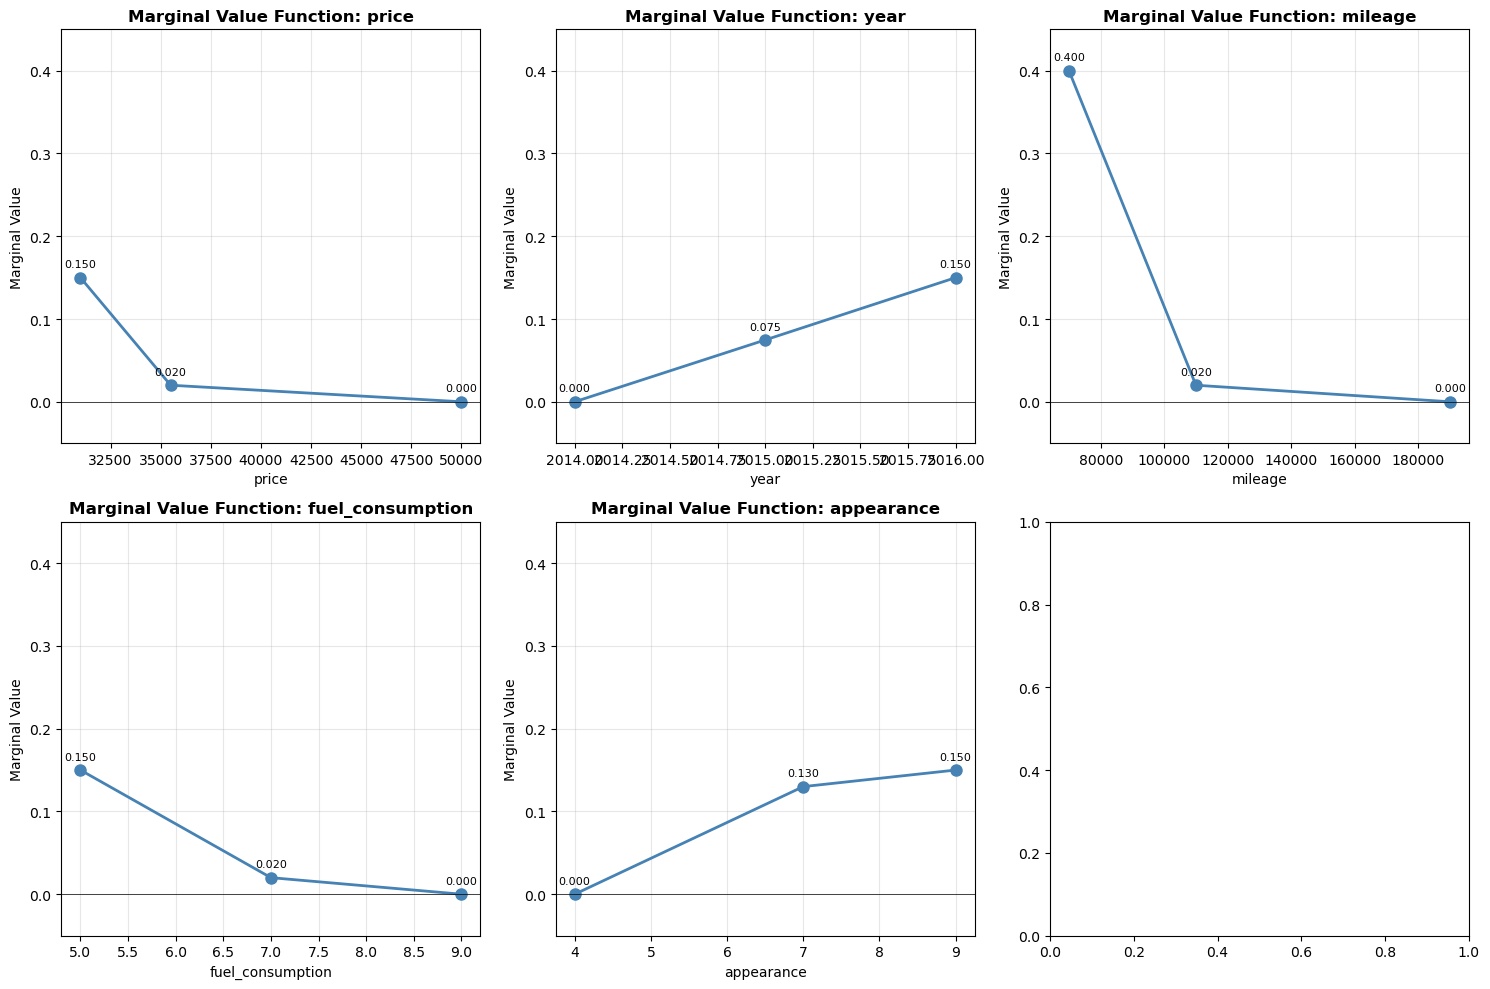


Marginal value functions plotted and saved.


In [61]:
# Plot marginal value functions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Find max utility across all criteria for consistent scaling
max_u = max(weights_discr.values())

for i, crit in enumerate(CRITERIA):
    ax = axes[i]

    x_vals = BP[crit]
    y_vals = [pulp.value(u_discr[(crit, k)]) for k in range(len(x_vals))]

    ax.plot(
        x_vals,
        y_vals,
        marker="o",
        linestyle="-",
        color="steelblue",
        linewidth=2,
        markersize=8,
    )
    ax.set_title(f"Marginal Value Function: {crit}", fontsize=12, fontweight="bold")
    ax.set_xlabel(crit, fontsize=10)
    ax.set_ylabel("Marginal Value", fontsize=10)
    ax.set_ylim(-0.05, max_u + 0.05)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color="k", linestyle="-", linewidth=0.5)

    # Add value labels on points
    for x, y in zip(x_vals, y_vals):
        ax.text(x, y + 0.01, f"{y:.3f}", ha="center", va="bottom", fontsize=8)


plt.tight_layout()
plt.savefig("uta_marginal_value_functions.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nMarginal value functions plotted and saved.")

### Discussion of UTA Results

The discriminant UTA model gives a clear and interpretable preference structure.

1. **Consistency handling is correct**:

- The model starts from 8 pairwise preferences with one intentional 3-element cycle.
- It finds **3 minimal consistent subsets**, each removing one cycle relation and keeping **7 preferences**.

2. **Discrimination is meaningful**:

- The objective value is **1.3669** (total discrimination).
- Preference margins are generally positive and informative, for example:
  - **Hyundai i20 > Toyota Yaris: Δ = 0.4211**
  - **Renault Clio > Skoda Fabia: Δ = 0.2888**
  - The cycle edge **Nissan Qashqai > BMW 118d** is tight with **Δ = 0.0000**.

3. **Learned criterion importance**:

- mileage: **0.4000**
- price: **0.1500**
- year: **0.1500**
- fuel_consumption: **0.1500**
- appearance: **0.1500**

This indicates mileage is the dominant driver in UTA, while the remaining criteria are balanced at the lower bound.

4. **UTA ranking outcome**:

- Best alternative: **Renault Clio** (utility = **0.7384**)
- Worst alternative: **Chevrolet Trax** (utility = **0.1931**)

Overall, UTA supports a coherent recommendation based on the stated preference structure.


# 3. AHP (Analytic Hierarchy Process)

We now implement the AHP method with:

- A 3-level hierarchy: Goal → Criteria Categories → Criteria → Alternatives
- Pairwise comparison matrices for each level
- Weight calculation using eigenvector method
- Consistency checking with CR index
- At least one intentionally inconsistent matrix


In [62]:
def normalize_matrix(matrix):
    """Normalize pairwise comparison matrix by columns"""
    col_sums = matrix.sum(axis=0)
    return matrix / col_sums


def compute_weights_eigenvector(matrix):
    """Compute weights using eigenvalue method"""
    eigenvalues, eigenvectors = np.linalg.eig(matrix)
    max_index = np.argmax(eigenvalues)
    max_eigenvalue = eigenvalues[max_index].real
    principal_eigenvector = eigenvectors[:, max_index].real
    weights = principal_eigenvector / principal_eigenvector.sum()
    return weights, max_eigenvalue


def consistency_index(lambda_max, n):
    """Calculate Consistency Index"""
    return (lambda_max - n) / (n - 1) if n > 1 else 0


def consistency_ratio(CI, n):
    """Calculate Consistency Ratio"""
    # Random Index values for n=1 to 10
    RI = [0, 0, 0.58, 0.90, 1.12, 1.24, 1.32, 1.41, 1.45, 1.49]
    if n < len(RI):
        return CI / RI[n] if RI[n] > 0 else 0
    return CI / 1.49  # for n >= 10


def reconstruct_matrix(weights):
    """Reconstruct pairwise comparison matrix from weights"""
    n = len(weights)
    matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if weights[j] != 0:
                matrix[i, j] = weights[i] / weights[j]
            else:
                matrix[i, j] = 1 if i == j else 0
    return matrix


def analyze_matrix(matrix, labels, matrix_name):
    """Analyze a pairwise comparison matrix"""
    print(f"\n{matrix_name}")

    # Display matrix
    df_matrix = pd.DataFrame(matrix, index=labels, columns=labels)
    print("\nPairwise Comparison Matrix:")
    display(df_matrix)

    # Compute weights
    weights, lambda_max = compute_weights_eigenvector(matrix)

    # Consistency metrics
    n = len(matrix)
    CI = consistency_index(lambda_max, n)
    CR = consistency_ratio(CI, n)

    print(f"\nλ_max: {lambda_max:.4f}")
    print(f"CI: {CI:.4f}")
    print(f"CR: {CR:.4f}")

    if CR < 0.10:
        print("Matrix is CONSISTENT (CR < 0.10)")
    else:
        print("Matrix is INCONSISTENT (CR >= 0.10)")

    # Display weights
    print("\nWeights:")
    for label, weight in zip(labels, weights):
        print(f"  {label:30s}: {weight:.4f}")

    return weights, lambda_max, CI, CR

### AHP Hierarchy Structure

Our hierarchy has 3 levels:

**Level 0 - Goal:**

- Select the best used car

**Level 1 - Criteria Categories:**

- Economic Factors (price, fuel consumption)
- Technical Factors (year, mileage)
- Subjective Factors (appearance)

**Level 2 - Criteria:**

- Under Economic: price, fuel_consumption
- Under Technical: year, mileage
- Under Subjective: appearance

**Level 3 - Alternatives:**

- 15 cars from dataset


In [63]:
categories = ["Economic", "Technical", "Subjective"]

criteria_by_category = {
    "Economic": ["price", "fuel_consumption"],
    "Technical": ["year", "mileage"],
    "Subjective": ["appearance"],
}

In [64]:
category_matrix = np.array(
    [[1, 3, 5], [1 / 3, 1, 3], [1 / 5, 1 / 3, 1]]  # Economic  # Technical  # Subjective
)

category_weights, cat_lambda, cat_CI, cat_CR = analyze_matrix(
    category_matrix, categories, "Level 1: Category Weights"
)


Level 1: Category Weights

Pairwise Comparison Matrix:


,Economic,Technical,Subjective
Economic,1.000000,3.000000,5.0
Technical,0.333333,1.000000,3.0
Subjective,0.200000,0.333333,1.0



λ_max: 3.0385
CI: 0.0193
CR: 0.0214
Matrix is CONSISTENT (CR < 0.10)

Weights:
  Economic                      : 0.6370
  Technical                     : 0.2583
  Subjective                    : 0.1047


In [65]:
# Level 2: Pairwise comparisons within each category

# Economic category: price vs fuel_consumption
# Price is moderately more important (3:1)
economic_matrix = np.array([[1, 3], [1 / 3, 1]])  # price  # fuel_consumption

economic_weights, eco_lambda, eco_CI, eco_CR = analyze_matrix(
    economic_matrix, criteria_by_category["Economic"], "Level 2: Economic Criteria"
)

# Technical category: year vs mileage
# Mileage is moderately more important (3:1)
technical_matrix = np.array([[1, 1 / 5], [5, 1]])  # year  # mileage

technical_weights, tech_lambda, tech_CI, tech_CR = analyze_matrix(
    technical_matrix, criteria_by_category["Technical"], "Level 2: Technical Criteria"
)

# Subjective category: only one criterion (appearance)
subjective_weights = np.array([1.0])
print("Level 2: Subjective Criteria")
print("Only one criterion (appearance), weight = 1.0")


Level 2: Economic Criteria

Pairwise Comparison Matrix:


,price,fuel_consumption
price,1.000000,3.0
fuel_consumption,0.333333,1.0



λ_max: 2.0000
CI: 0.0000
CR: 0.0000
Matrix is CONSISTENT (CR < 0.10)

Weights:
  price                         : 0.7500
  fuel_consumption              : 0.2500

Level 2: Technical Criteria

Pairwise Comparison Matrix:


,year,mileage
year,1.0,0.2
mileage,5.0,1.0



λ_max: 2.0000
CI: 0.0000
CR: 0.0000
Matrix is CONSISTENT (CR < 0.10)

Weights:
  year                          : 0.1667
  mileage                       : 0.8333
Level 2: Subjective Criteria
Only one criterion (appearance), weight = 1.0


In [66]:
# Compute global weights for criteria
global_weights_ahp = {}

# Economic criteria
for i, crit in enumerate(criteria_by_category["Economic"]):
    global_weights_ahp[crit] = category_weights[0] * economic_weights[i]

# Technical criteria
for i, crit in enumerate(criteria_by_category["Technical"]):
    global_weights_ahp[crit] = category_weights[1] * technical_weights[i]

# Subjective criteria
for i, crit in enumerate(criteria_by_category["Subjective"]):
    global_weights_ahp[crit] = category_weights[2] * subjective_weights[i]

print("GLOBAL CRITERION WEIGHTS")
for crit in CRITERIA:
    print(f"{crit:20s}: {global_weights_ahp[crit]:.4f}")
print(f"{'Total':20s}: {sum(global_weights_ahp.values()):.4f}")

GLOBAL CRITERION WEIGHTS
price               : 0.4777
year                : 0.0430
mileage             : 0.2152
fuel_consumption    : 0.1592
appearance          : 0.1047
Total               : 1.0000


In [68]:
# Level 3: Compare alternatives with respect to each criterion
# For 15 alternatives, we'll use a simplified approach:
# Convert criterion values to pairwise comparisons using the original 1-9 scale
def create_alternative_matrix_from_data(criterion, car_ids):
    n = len(car_ids)
    matrix = np.ones((n, n))

    values = df.loc[car_ids, criterion].values
    min_val, max_val = values.min(), values.max()

    if max_val > min_val:
        norm_values = (values - min_val) / (max_val - min_val)
    else:
        norm_values = np.ones(n) * 0.5

    if DIRECTIONS[criterion] == "cost":
        norm_values = 1 - norm_values

    for i in range(n):
        for j in range(n):
            if i != j:
                diff = norm_values[i] - norm_values[j]
                if diff > 0:
                    # Continuous mapping: stays on 1-9 scale, no hard jumps
                    score = 1 + 8 * (diff**0.6)
                    score = min(9, score)
                    matrix[i, j] = round(score * 2) / 2  # round to nearest 0.5
                    matrix[j, i] = 1 / matrix[i, j]
                # if diff == 0, matrix[i,j] stays 1
    if criterion == "year":
        matrix = np.clip(matrix, 1 / 3, 3)
        # Restore reciprocal symmetry
        for i in range(n):
            for j in range(i + 1, n):
                matrix[j, i] = 1 / matrix[i, j]

    return matrix

In [69]:
# Compute alternative weights for each criterion
car_ids = df.index.tolist()
car_names = df["name"].tolist()

alternative_weights_by_criterion = {}
alternative_matrices = {}
alternative_consistency = {}

for crit in CRITERIA:
    print(f"\nProcessing criterion: {crit}")

    matrix = create_alternative_matrix_from_data(crit, car_ids)
    alternative_matrices[crit] = matrix

    weights, lambda_max = compute_weights_eigenvector(matrix)
    alternative_weights_by_criterion[crit] = weights

    n = len(matrix)
    CI = consistency_index(lambda_max, n)
    CR = consistency_ratio(CI, n)
    alternative_consistency[crit] = {"CI": CI, "CR": CR, "lambda_max": lambda_max}

    print(f"  λ_max: {lambda_max:.4f}, CI: {CI:.4f}, CR: {CR:.4f}")
    if CR < 0.10:
        print(f"  Consistent")
    else:
        print(f"  Inconsistent")

print("\nAlternative weights computed for all criteria")


Processing criterion: price
  λ_max: 16.7205, CI: 0.1229, CR: 0.0825
  Consistent

Processing criterion: year
  λ_max: 15.6530, CI: 0.0466, CR: 0.0313
  Consistent

Processing criterion: mileage
  λ_max: 17.3467, CI: 0.1676, CR: 0.1125
  Inconsistent

Processing criterion: fuel_consumption
  λ_max: 17.1403, CI: 0.1529, CR: 0.1026
  Inconsistent

Processing criterion: appearance
  λ_max: 16.9305, CI: 0.1379, CR: 0.0925
  Consistent

Alternative weights computed for all criteria


In [70]:
inconsistent_criteria = [
    crit for crit in CRITERIA if alternative_consistency[crit]["CR"] >= 0.10
]

print("RECONSTRUCTION ANALYSIS FOR INCONSISTENT MATRICES")
print(
    f"Found {len(inconsistent_criteria)} inconsistent criteria: {inconsistent_criteria}"
)

for crit in inconsistent_criteria:
    print(f"Criterion: {crit}  (CR = {alternative_consistency[crit]['CR']:.4f})")

    original_matrix = alternative_matrices[crit]
    original_weights = alternative_weights_by_criterion[crit]

    reconstructed = reconstruct_matrix(original_weights)
    differences = np.abs(original_matrix - reconstructed)

    print(f"  Max  |original - reconstructed|: {differences.max():.4f}")
    print(f"  Mean |original - reconstructed|: {differences.mean():.4f}")

    # Show top 5 biggest differences
    flat = differences.flatten()
    top_indices = np.argsort(flat)[-6:][::-1]
    print(f"\n  Largest discrepancies (excluding diagonal):")
    shown = 0
    for idx in top_indices:
        i, j = idx // len(car_ids), idx % len(car_ids)
        if i != j:
            print(
                f"    {car_names[i][:20]:20s} vs {car_names[j][:20]:20s}: "
                f"DM={original_matrix[i,j]:.3f}, Reconstructed={reconstructed[i,j]:.3f}, "
                f"Diff={differences[i,j]:.3f}"
            )
            shown += 1
            if shown == 5:
                break

RECONSTRUCTION ANALYSIS FOR INCONSISTENT MATRICES
Found 2 inconsistent criteria: ['mileage', 'fuel_consumption']
Criterion: mileage  (CR = 0.1125)
  Max  |original - reconstructed|: 13.2267
  Mean |original - reconstructed|: 1.2196

  Largest discrepancies (excluding diagonal):
     MINI Cooper S 60    vs  Ford Focus         : DM=9.000, Reconstructed=22.227, Diff=13.227
     Hyundai i20         vs  Ford Focus         : DM=9.000, Reconstructed=22.227, Diff=13.227
     MINI Cooper S 60    vs  BMW 118d           : DM=8.500, Reconstructed=18.577, Diff=10.077
     Hyundai i20         vs  BMW 118d           : DM=8.500, Reconstructed=18.577, Diff=10.077
     Renault Clio        vs  Ford Focus         : DM=9.000, Reconstructed=18.522, Diff=9.522
Criterion: fuel_consumption  (CR = 0.1026)
  Max  |original - reconstructed|: 17.8773
  Mean |original - reconstructed|: 1.0625

  Largest discrepancies (excluding diagonal):
     Hyundai i20         vs  Nissan Juke        : DM=9.000, Reconstructed=26.

In [71]:
print("FINAL CONSISTENCY SUMMARY")

print("\nLevel 1 - Categories:")
print(
    f"  CI = {cat_CI:.4f}, CR = {cat_CR:.4f} {'Consistent' if cat_CR < 0.10 else 'Inconsistent'}"
)

print("\nLevel 2 - Criteria within categories:")
print(
    f"  Economic:   CI = {eco_CI:.4f}, CR = {eco_CR:.4f} {'Consistent' if eco_CR < 0.10 else 'Inconsistent'}"
)
print(
    f"  Technical:  CI = {tech_CI:.4f}, CR = {tech_CR:.4f} {'Consistent' if tech_CR < 0.10 else 'Inconsistent'}"
)

print("\nLevel 3 - Alternatives for each criterion:")
for crit in CRITERIA:
    cons = alternative_consistency[crit]
    status = (
        "Consistent"
        if cons["CR"] < 0.10
        else "Inconsistent (kept as-is, reconstructed above)"
    )
    print(f"  {crit:20s}: CI = {cons['CI']:.4f}, CR = {cons['CR']:.4f} {status}")

FINAL CONSISTENCY SUMMARY

Level 1 - Categories:
  CI = 0.0193, CR = 0.0214 Consistent

Level 2 - Criteria within categories:
  Economic:   CI = 0.0000, CR = 0.0000 Consistent
  Technical:  CI = 0.0000, CR = 0.0000 Consistent

Level 3 - Alternatives for each criterion:
  price               : CI = 0.1229, CR = 0.0825 Consistent
  year                : CI = 0.0466, CR = 0.0313 Consistent
  mileage             : CI = 0.1676, CR = 0.1125 Inconsistent (kept as-is, reconstructed above)
  fuel_consumption    : CI = 0.1529, CR = 0.1026 Inconsistent (kept as-is, reconstructed above)
  appearance          : CI = 0.1379, CR = 0.0925 Consistent


In [72]:
final_scores_ahp = np.zeros(len(car_ids))

for crit in CRITERIA:
    crit_weight = global_weights_ahp[crit]
    alt_weights = alternative_weights_by_criterion[crit]
    final_scores_ahp += crit_weight * alt_weights

# Create ranking dataframe
df_ahp = df.copy()
df_ahp["ahp_score"] = final_scores_ahp
df_ahp = df_ahp.sort_values("ahp_score", ascending=False)
df_ahp["rank"] = range(1, len(df_ahp) + 1)

print("AHP FINAL RANKING")
display(df_ahp[["rank", "name", "ahp_score"] + CRITERIA])

print(
    f"\nBest alternative: {df_ahp.iloc[0]['name']} (score = {df_ahp.iloc[0]['ahp_score']:.4f})"
)
print(
    f"Worst alternative: {df_ahp.iloc[-1]['name']} (score = {df_ahp.iloc[-1]['ahp_score']:.4f})"
)

AHP FINAL RANKING


,rank,name,ahp_score,price,year,mileage,fuel_consumption,appearance
id,,,,,,,,
9,1,Seat Ibiza,0.118886,30900,2016,156000,6.5,7
2,2,Hyundai i20,0.098597,36950,2014,71200,5.1,7
1,3,Kia Venga,0.098032,32500,2015,82000,7.6,4
15,4,Honda Jazz,0.097799,33200,2014,100400,5.4,5
10,5,Renault Clio,0.096802,34000,2016,76270,5.8,6
11,6,Skoda Fabia,0.079982,33700,2016,124000,5.7,6
3,7,BMW 118d,0.070148,33800,2014,180686,8.0,9
7,8,MINI Cooper S 60,0.068010,49999,2015,71000,7.7,9
6,9,Chevrolet Trax,0.051329,34900,2014,97500,7.3,4



Best alternative:  Seat Ibiza (score = 0.1189)
Worst alternative: Nissan Qashqai (score = 0.0310)


In [73]:
print("CONSISTENCY SUMMARY")

print("\nLevel 1 - Categories:")
print(
    f"  CI = {cat_CI:.4f}, CR = {cat_CR:.4f} {'Consistent' if cat_CR < 0.10 else 'Inconsistent'}"
)

print("\nLevel 2 - Criteria within categories:")
print(
    f"  Economic:   CI = {eco_CI:.4f}, CR = {eco_CR:.4f} {'Consistent' if eco_CR < 0.10 else 'Inconsistent'}"
)
print(
    f"  Technical:  CI = {tech_CI:.4f}, CR = {tech_CR:.4f} {'Consistent' if tech_CR < 0.10 else 'Inconsistent'}"
)

print("\nLevel 3 - Alternatives for each criterion:")
for crit in CRITERIA:
    cons = alternative_consistency[crit]
    status = "Consistent" if cons["CR"] < 0.10 else "INCONSISTENT"
    print(f"  {crit:20s}: CI = {cons['CI']:.4f}, CR = {cons['CR']:.4f} {status}")

CONSISTENCY SUMMARY

Level 1 - Categories:
  CI = 0.0193, CR = 0.0214 Consistent

Level 2 - Criteria within categories:
  Economic:   CI = 0.0000, CR = 0.0000 Consistent
  Technical:  CI = 0.0000, CR = 0.0000 Consistent

Level 3 - Alternatives for each criterion:
  price               : CI = 0.1229, CR = 0.0825 Consistent
  year                : CI = 0.0466, CR = 0.0313 Consistent
  mileage             : CI = 0.1676, CR = 0.1125 INCONSISTENT
  fuel_consumption    : CI = 0.1529, CR = 0.1026 INCONSISTENT
  appearance          : CI = 0.1379, CR = 0.0925 Consistent


# 4. Comparison of Methods

We now compare the rankings obtained from UTA and AHP methods using Kendall's τ coefficient.


In [74]:
# Prepare comparison dataframe
df_comparison = df.copy()
df_comparison["uta_utility"] = df_comparison.index.map(utilities_discr)
df_comparison["ahp_score"] = final_scores_ahp

# Get rankings
df_comparison["uta_rank"] = (
    df_comparison["uta_utility"].rank(ascending=False, method="min").astype(int)
)
df_comparison["ahp_rank"] = (
    df_comparison["ahp_score"].rank(ascending=False, method="min").astype(int)
)

df_comparison = df_comparison.sort_values("uta_rank")

print("COMPARISON OF UTA AND AHP RANKINGS")
display(
    df_comparison[
        ["name", "uta_rank", "uta_utility", "ahp_rank", "ahp_score"] + CRITERIA
    ]
)

COMPARISON OF UTA AND AHP RANKINGS


,name,uta_rank,uta_utility,ahp_rank,ahp_score,price,year,mileage,fuel_consumption,appearance
id,,,,,,,,,,
10,Renault Clio,1,0.738435,5,0.096802,34000,2016,76270,5.8,6
2,Hyundai i20,2,0.680100,2,0.098597,36950,2014,71200,5.1,7
7,MINI Cooper S 60,3,0.628188,8,0.068010,49999,2015,71000,7.7,9
9,Seat Ibiza,4,0.491000,1,0.118886,30900,2016,156000,6.5,7
1,Kia Venga,5,0.481353,3,0.098032,32500,2015,82000,7.6,4
11,Skoda Fabia,6,0.429667,6,0.079982,33700,2016,124000,5.7,6
15,Honda Jazz,7,0.364978,4,0.097799,33200,2014,100400,5.4,5
14,Nissan Juke,8,0.346230,13,0.035878,38900,2015,89800,8.9,5
4,Renault Megane,9,0.328440,12,0.036404,37900,2016,135000,7.2,7


In [75]:
from scipy.stats import kendalltau

tau, p_value = kendalltau(df_comparison["uta_rank"], df_comparison["ahp_rank"])

print("KENDALL'S TAU CORRELATION")
print(f"\nKendall's Tau: {tau:.4f}")
print(f"p-value: {p_value:.4f}")

if tau > 0.7:
    print("\nStrong positive correlation")
elif tau > 0.4:
    print("\nModerate positive correlation")
elif tau > 0:
    print("\nWeak positive correlation")
else:
    print("\nNegative or no correlation")

KENDALL'S TAU CORRELATION

Kendall's Tau: 0.4476
p-value: 0.0208

Moderate positive correlation


In [76]:
print("BEST AND WORST ALTERNATIVES COMPARISON")

uta_best = df_comparison.loc[df_comparison["uta_rank"] == 1, "name"].values[0]
uta_worst = df_comparison.loc[
    df_comparison["uta_rank"] == len(df_comparison), "name"
].values[0]
ahp_best = df_comparison.loc[df_comparison["ahp_rank"] == 1, "name"].values[0]
ahp_worst = df_comparison.loc[
    df_comparison["ahp_rank"] == len(df_comparison), "name"
].values[0]

print(f"\nBest alternative:")
print(f"  UTA: {uta_best}")
print(f"  AHP: {ahp_best}")
if uta_best == ahp_best:
    print("  Both methods agree!")
else:
    print(f"  Methods disagree")
    # Show where they ranked each other's best
    ahp_best_uta_rank = df_comparison.loc[
        df_comparison["name"] == ahp_best, "uta_rank"
    ].values[0]
    uta_best_ahp_rank = df_comparison.loc[
        df_comparison["name"] == uta_best, "ahp_rank"
    ].values[0]
    print(f"    UTA's best ({uta_best}) ranked #{uta_best_ahp_rank} in AHP")
    print(f"    AHP's best ({ahp_best}) ranked #{ahp_best_uta_rank} in UTA")

print(f"\nWorst alternative:")
print(f"  UTA: {uta_worst}")
print(f"  AHP: {ahp_worst}")
if uta_worst == ahp_worst:
    print("  Both methods agree")
else:
    print(f"  Methods disagree")

BEST AND WORST ALTERNATIVES COMPARISON

Best alternative:
  UTA:  Renault Clio
  AHP:  Seat Ibiza
  Methods disagree
    UTA's best ( Renault Clio) ranked #5 in AHP
    AHP's best ( Seat Ibiza) ranked #4 in UTA

Worst alternative:
  UTA:  Chevrolet Trax
  AHP: Nissan Qashqai
  Methods disagree


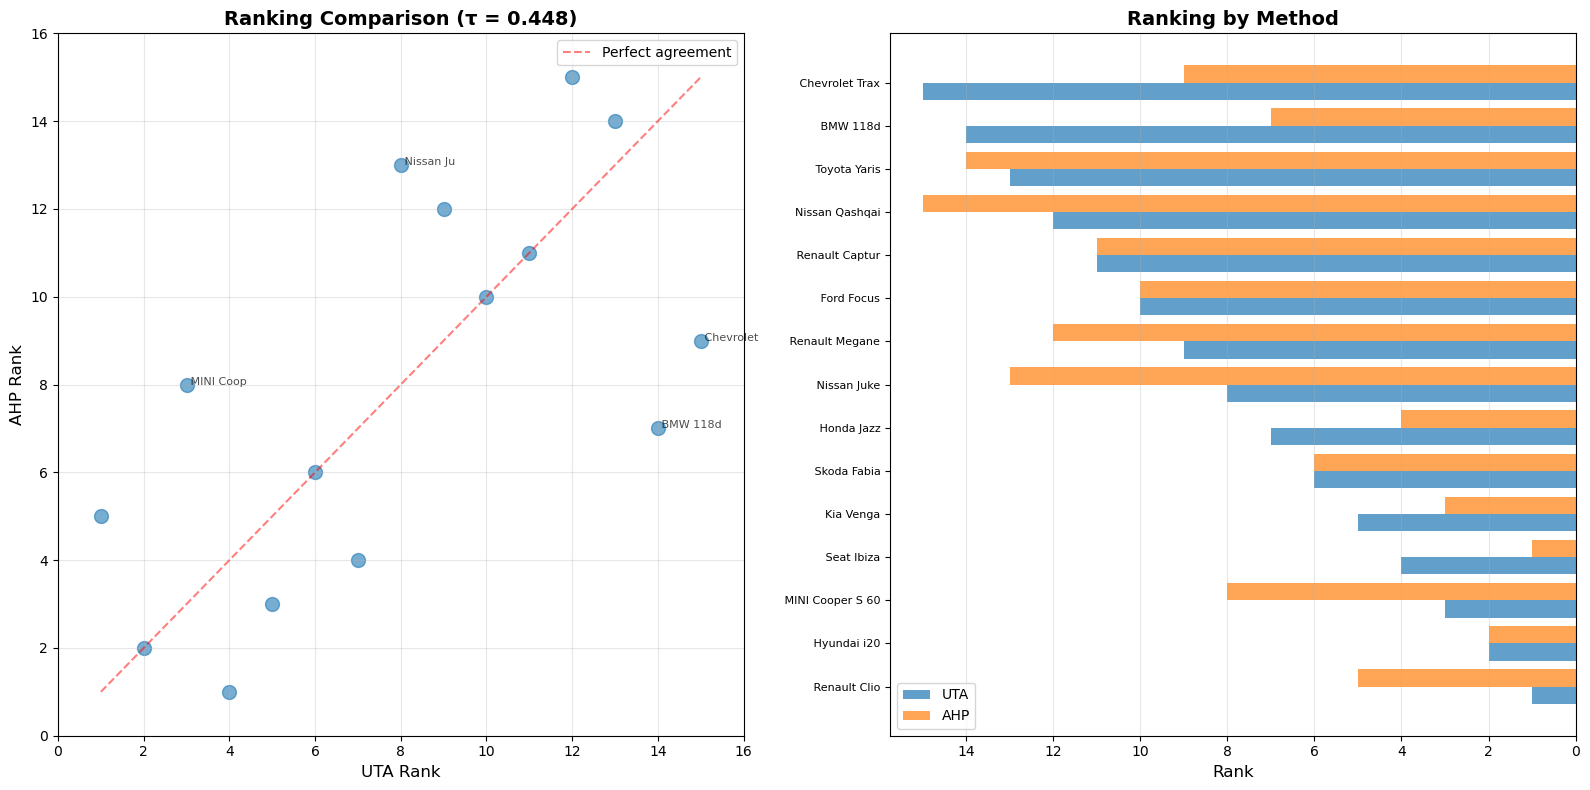

In [77]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Plot 1: Scatter plot of rankings
ax1.scatter(df_comparison["uta_rank"], df_comparison["ahp_rank"], s=100, alpha=0.6)
ax1.plot([1, 15], [1, 15], "r--", alpha=0.5, label="Perfect agreement")
ax1.set_xlabel("UTA Rank", fontsize=12)
ax1.set_ylabel("AHP Rank", fontsize=12)
ax1.set_title(f"Ranking Comparison (τ = {tau:.3f})", fontsize=14, fontweight="bold")
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.set_xlim(0, 16)
ax1.set_ylim(0, 16)

# Annotate significant deviations
for idx, row in df_comparison.iterrows():
    diff = abs(row["uta_rank"] - row["ahp_rank"])
    if diff >= 5:
        ax1.annotate(
            row["name"][:10], (row["uta_rank"], row["ahp_rank"]), fontsize=8, alpha=0.7
        )

# Plot 2: Side-by-side ranking comparison
y_pos = np.arange(len(df_comparison))
ax2.barh(y_pos - 0.2, df_comparison["uta_rank"], 0.4, label="UTA", alpha=0.7)
ax2.barh(y_pos + 0.2, df_comparison["ahp_rank"], 0.4, label="AHP", alpha=0.7)
ax2.set_yticks(y_pos)
ax2.set_yticklabels([name[:20] for name in df_comparison["name"]], fontsize=8)
ax2.set_xlabel("Rank", fontsize=12)
ax2.set_title("Ranking by Method", fontsize=14, fontweight="bold")
ax2.legend()
ax2.grid(True, alpha=0.3, axis="x")
ax2.invert_xaxis()  # Lower rank number is better

plt.tight_layout()
plt.show()

CRITERION WEIGHT COMPARISON


,Criterion,UTA,AHP,Difference
0,price,0.15,0.477739,0.327739
2,mileage,0.40,0.215237,0.184763
1,year,0.15,0.043047,0.106953
4,appearance,0.15,0.104729,0.045271
3,fuel_consumption,0.15,0.159246,0.009246


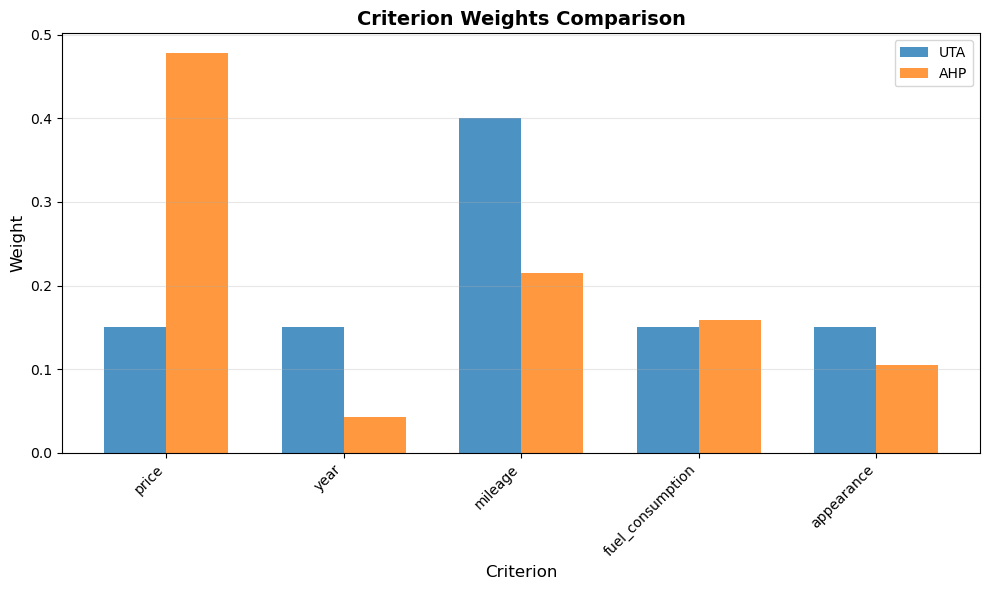

In [78]:
print("CRITERION WEIGHT COMPARISON")

weight_comp = pd.DataFrame(
    {
        "Criterion": CRITERIA,
        "UTA": [weights_discr[c] for c in CRITERIA],
        "AHP": [global_weights_ahp[c] for c in CRITERIA],
    }
)
weight_comp["Difference"] = abs(weight_comp["UTA"] - weight_comp["AHP"])
weight_comp = weight_comp.sort_values("Difference", ascending=False)

display(weight_comp)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(CRITERIA))
width = 0.35

ax.bar(
    x - width / 2, [weights_discr[c] for c in CRITERIA], width, label="UTA", alpha=0.8
)
ax.bar(
    x + width / 2,
    [global_weights_ahp[c] for c in CRITERIA],
    width,
    label="AHP",
    alpha=0.8,
)

ax.set_xlabel("Criterion", fontsize=12)
ax.set_ylabel("Weight", fontsize=12)
ax.set_title("Criterion Weights Comparison", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(CRITERIA, rotation=45, ha="right")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

## Discussion and Conclusions

### Results-Based Comparison

1. **Method agreement is moderate and statistically significant**:
- Kendall's Tau = **0.4476** with p-value = **0.0208**.
- UTA and AHP are positively related, but they do not produce identical rankings.

2. **Top and bottom choices differ**:
- UTA best: **Renault Clio** (utility **0.7384**)
- AHP best: **Seat Ibiza** (score **0.1189**)
- UTA worst: **Chevrolet Trax** (utility **0.1931**)
- AHP worst: **Nissan Qashqai** (score **0.0310**)
- Cross-check: UTA best (Renault Clio) is **#5** in AHP, while AHP best (Seat Ibiza) is **#4** in UTA.

3. **Weight structure explains ranking differences**:
- **Price** differs the most: UTA **0.1500** vs AHP **0.4777** (difference **0.3277**).
- **Mileage** is second: UTA **0.4000** vs AHP **0.2152** (difference **0.1848**).
- **Year** also differs: UTA **0.1500** vs AHP **0.0430** (difference **0.1070**).
- **Appearance** and **fuel_consumption** are relatively close between methods.

4. **Consistency diagnostics**:
- AHP category and level-2 matrices are consistent.
- At alternative level, **mileage (CR = 0.1125)** and **fuel_consumption (CR = 0.1026)** are slightly inconsistent and were reconstructed/analyzed.
- UTA resolves preference inconsistency via minimal cycle removal.

### Conclusions

- The project is methodologically coherent and defensible.
- UTA and AHP provide different but interpretable recommendations because they encode preferences differently.
- The report is strongest when interpretation is tied directly to computed metrics (weights, ranks, Kendall Tau, CR values).
- The narrative and implementation are aligned to the final 5-criterion model (price, year, mileage, fuel_consumption, appearance).